---
title: Is it hacked?
author: Mihail Plesa
categories: ['ml-cybersecurity']
date: 04/15/2023
format:
  html:
    code-fold: false
---


# Is it hacked? 
## Detecting web defacement with deep learning using fastai library

## Introduction

In this short tutorial, we construct a simple classifier for detecting web defacement using fast.ai library. Currently, I'm taking Jeremy Howard's course ([Practical Deep Learning for Coders - Part 1](https://course.fast.ai)) and I'm thrilled about it. I've coded various DL models in the past (especially for cybersecurity), but I only used TensorFlow. 
Recently, I wanted to try PyTorch since it seems that it takes over the market. In the past, I had heard of fastai as a PyTorch-based library, but because I was using TensorFlow, I didn't pay much attention to it. 
Now, I'm impressed by what this library can do and I want to share this with you. 
Don't expect to see a state-of-the-art model, I'm only experimenting with fastai for cybersecurity related problems 😁

Just to be more clear: you know when a website is hacked and the hackers display some message on the home page? 
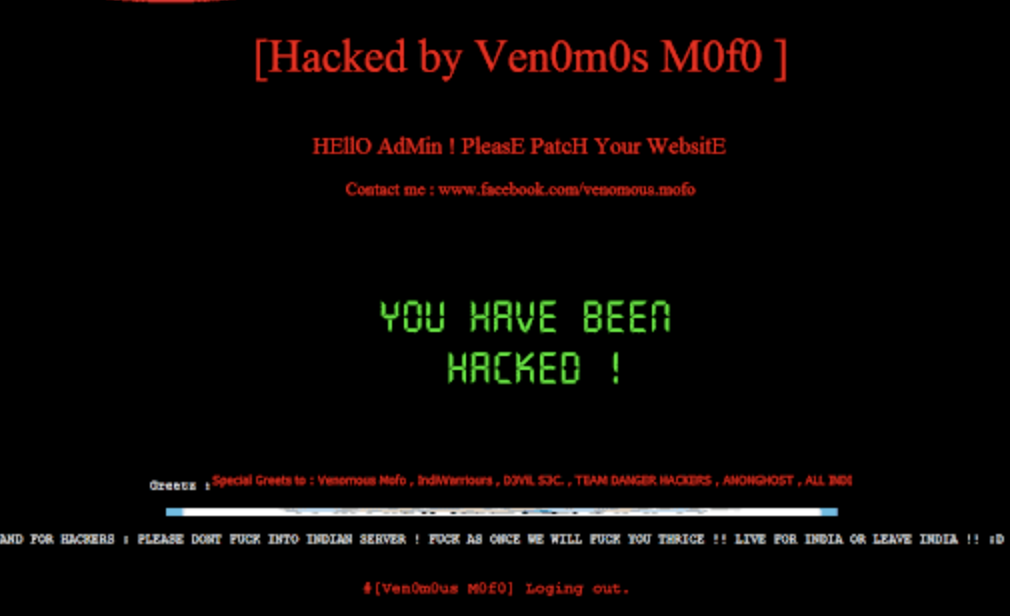


This is web defacement and this we are trying to detect it. Why? Well, if your site was defaced, the first thing you do is to put it in maintenance mode. Wouldn't it be nice if you had a DL model that would warn you instantly when a website has been defaced? If you want to know how you might do that, keep reading 🤓

## Step 1: Download images of defaced and non-defaced websites

We will use duckduckgo_search to construct our dataset of defaced and non-defaced websites. 

In [ ]:
from duckduckgo_search import ddg_images
from fastcore.all import *
from fastai.vision.widgets import *

In [ ]:
def search_images(term, max_images=50):
    print(f"Searching for '{term}'")
    return L(ddg_images(term, max_results=max_images)).itemgot('image')

Here is an example:

In [26]:
urls = search_images('example of defaced webpage', max_images=1)
urls[0]

Searching for 'example of defaced webpage'


'https://blog.sucuri.net/wp-content/uploads/2020/04/image1-600x419.png'

Now, we download the image from that URL and saved it locally in a file named defaced.jpg. To do this, we use another "fast" library called [fastdownload](https://fastdownload.fast.aihttps://fastdownload.fast.ai). 

In [5]:
from fastdownload import download_url
dest = 'defaced.jpg'
download_url(urls[0], dest, show_progress=False)

Path('defaced.jpg')

To check if we saved the right image, we open it using [PIL](https://pillow.readthedocs.io/en/stable/). The [to_thumb](https://docs.fast.ai/vision.core.html#image.to_thumb) function produces a 256x256 thumbnail version of the image.

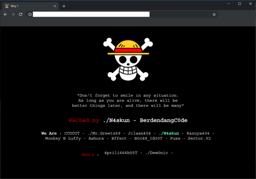

In [6]:
from fastai.vision.all import *
im = Image.open(dest)
im.to_thumb(256,256)

Now we repeat for a non-defaced website.

Searching for 'example of normal webpage'


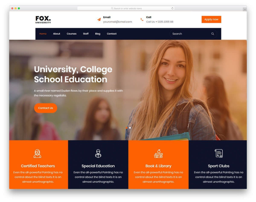

In [7]:
download_url(search_images('example of normal webpage', max_images=1)[0], 'non-defaced.jpg', show_progress=False)
Image.open('non-defaced.jpg').to_thumb(256,256)

Let's build our dataset. We search for defaced and on-defaced websites.

In [ ]:
searches = ['defaced website','nice homepage site example']
local = ['d', 'nd']
path = Path('defaced_or_not')
from time import sleep

for idx in range(2):
    dest = (path/local[idx])
    print(path, local[idx] , dest)
    dest.mkdir(exist_ok=True, parents=True)
    download_images(dest, urls=search_images(searches[idx]))
    sleep(10)
    resize_images(path/local[idx], max_size=400, dest=path/local[idx])

Delete all images that were downloaded incorrectly.

In [18]:
failed = verify_images(get_image_files(path))
failed.map(Path.unlink)
len(failed)

0

In [19]:
print(len(os.listdir(path/'d')))
print(len(os.listdir(path/'nd')))

47
48


We have 47 images of defaced websites and 48 images of non-defaced websites.

## Step 2: Train the model

To train the model we first construct a [DataBlock](https://docs.fast.ai/data.block.html). In a `DataBlock` we specify how to split the data in training and validation, how to label the training images (defaced or non-defaced) and how to pre-process the images (for example, we resize all the images using a common dimension). Using `fastai` we can make all of these in a single line of code 🥹.

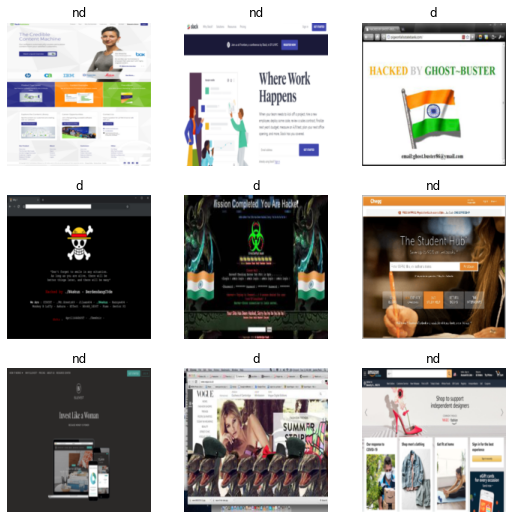

In [20]:
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock), 
    get_items=get_image_files, 
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=[Resize(192, method='squish')]
).dataloaders(path, bs=32)

dls.show_batch(max_n=9)

Now we are ready to train the model. Here is the trick: we use something called transfer learning. We borrow the knowledge from a very big pre-trained model like `resnet18` and customize that knowledge for our use case. It's like getting knowledge about mathematics in general and then getting specialized in derivatives 

In [21]:
learn = vision_learner(dls, resnet18, metrics=error_rate)
learn.fine_tune(8)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


  0%|          | 0.00/44.7M [00:00<?, ?B/s]

epoch,train_loss,valid_loss,error_rate,time
0,1.430695,0.622086,0.315789,00:07


epoch,train_loss,valid_loss,error_rate,time
0,0.767509,0.755880,0.368421,00:01
1,0.668098,0.829260,0.368421,00:00
2,0.580183,0.730606,0.315789,00:00
3,0.442123,0.641195,0.263158,00:00
4,0.366080,0.600636,0.263158,00:00
5,0.301277,0.524480,0.210526,00:00
6,0.254276,0.463378,0.105263,00:00
7,0.218404,0.426965,0.105263,00:00


We get almost 90% accuracy on the validation dataset which is great for a first try 🥳

Here is the confusion matrix for the validation dataset. The confusion matrix tells us:
1. How many defaced websites were labeled as defaced (True Positives)
2. How many defaced websites were labeled as non-defaced (False negatives)
3. How many non-defaced webistes were labeled as defaced (False positives)
4. How many non-defaced websites were labeled as non-defaced (True Negatives)

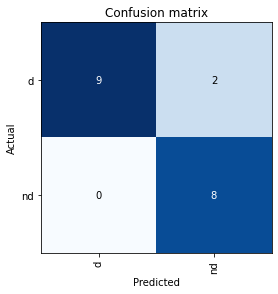

In [22]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()

## Step 3: Use the model

Let's see what our model thinks about that defaced.jpg we downloaded at the start:

In [23]:
is_defaced,_,probs = learn.predict(PILImage.create('defaced.jpg'))
print(f"This is a: {is_defaced}.")
print(f"Probability it's a defaced: {probs[0]:.4f}")

This is a: d.
Probability it's a defaced: 0.9962


## Conclusions
In this short blog post, we constructed a simple classifier to detect web defacement. Our classifier gets 80% accuracy on the validation dataset. I will continue to improve it as I follow the course, so stay tuned 😎

This post is based on the [first lab](https://www.kaggle.com/code/jhoward/is-it-a-bird-creating-a-model-from-your-own-data) of the [fast.ai](https://course.fast.ai) coure so thank you [Jeremy Howard](https://twitter.com/jeremyphoward) 😃
![](https://pbs.twimg.com/media/Ff_o_toXgAELiDm?format=jpg&name=medium)